In [1]:
import os
import yaml
import numpy as np
import pandas as pd
from pathlib import Path
import glob
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from tqdm import tqdm

import sys
import os
from pathlib import Path

current_dir = Path.cwd()
parent_dir = str(current_dir.parent)

# もし絶対パスで指定してしまった方が確実なら、以下でもOKです
# parent_dir = "/home/user/project_name" 

if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
    print(f"Added to sys.path: {parent_dir}")

from Analysis import get_spike_indices, calculate_effective_rank

Added to sys.path: /home/satoshi/NeuMoReservoir


In [2]:
# ==========================================
# 2. メイン解析関数
# ==========================================
def analyze_effective_rank_multirun(base_path):
    base_dir = Path(base_path)
    job_dirs = sorted([d for d in base_dir.iterdir() if d.is_dir() and d.name.isdigit()], 
                      key=lambda x: int(x.name))
    
    all_spike_data = []
    window_ms = 5.0  # ランク計算用の窓幅

    for job_dir in job_dirs:
        cfg_path = job_dir / ".hydra" / "config.yaml"
        if not cfg_path.exists(): continue
        with open(cfg_path, "r") as f:
            cfg = yaml.safe_load(f)
        
        syn_mean = cfg.get("syn_loc_mean")
        syn_std = cfg.get("syn_loc_std")
        
        buffer_files = glob.glob(str(job_dir / "data" / "buffer*.npz"))
        #for bf in buffer_files:
        for bf in tqdm(buffer_files, desc=f"  Job {job_dir.name}", leave=False):
            data_ts = np.load(bf, allow_pickle=True)
            t = data_ts['t_rec']
            ca = data_ts['variables'][0] # Ca (T, N)
            vm = data_ts['variables'][1] # Vm (T, N)
            dt = t[1] - t[0]
            window_size = int(window_ms / dt)
            
            # 常に (T, N) に統一
            if ca.shape[1] > ca.shape[0]:
                ca = ca.T
                vm = vm.T
            
            # PCAによる残差成分の計算
            # sklearnのPCAは (n_samples, n_features) すなわち (T, N) を期待する
            pca = PCA(n_components=1)
            ca_pca = pca.fit_transform(ca)   # PC1スコアを取得
            ca_proj = pca.inverse_transform(ca_pca) # PC1で再構成
            ca_res = ca - ca_proj           # 残差 (T, N)
            
            # スパイク検出 (vmは (T, N) なので axis=1 で平均をとる)
            bap_idxs, dap_idxs = get_spike_indices(vm, t, v_threshold=-30)
            
            # 各スパイクにおけるランク計算
            for s_type, idxs in [("bAP", bap_idxs), ("dAP", dap_idxs)]:
                for idx in idxs:
                    if idx < window_size // 2 or idx > ca.shape[0] - window_size // 2:
                        continue
                        
                    w_start = idx - window_size // 2
                    w_end = idx + window_size // 2
                    
                    # sub_data は (window_size, N_compartments)
                    er_orig = calculate_effective_rank(ca[w_start:w_end, :])
                    er_res = calculate_effective_rank(ca_res[w_start:w_end, :])
                    
                    all_spike_data.append({
                        "job_id": job_dir.name,
                        "syn_loc_mean": syn_mean,
                        "syn_loc_std": syn_std,
                        "spike_type": s_type,
                        "er_orig": er_orig,
                        "er_res": er_res
                    })
                    
    return pd.DataFrame(all_spike_data)

In [3]:
# --- 実行とプロット ---
MULTIRUN_PATH = "../multirun/2026-04-15/11-30-35" # 実際のパス
df_rank = analyze_effective_rank_multirun(MULTIRUN_PATH)

# 条件（mean, std）の組み合わせごとにsubplotを作成
conditions = df_rank.groupby(['syn_loc_mean', 'syn_loc_std']).size().index
n_conds = len(conditions)

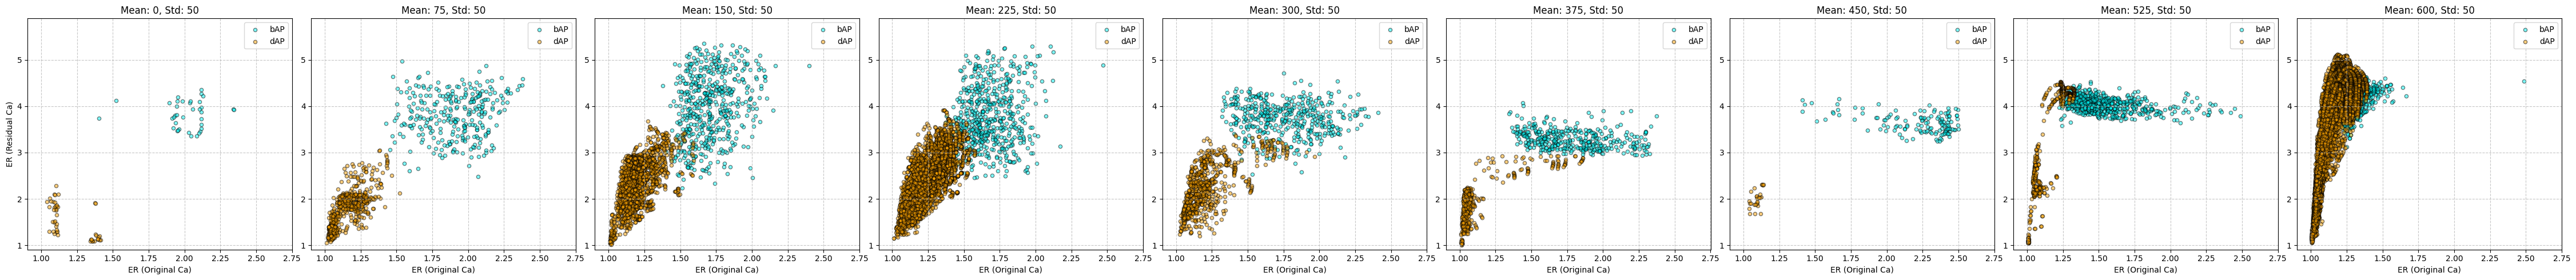

In [4]:
# 1. 全データから軸の限界値を決定する
if not df_rank.empty:
    x_min, x_max = df_rank['er_orig'].min(), df_rank['er_orig'].max()
    y_min, y_max = df_rank['er_res'].min(), df_rank['er_res'].max()
    
    # 少し余白を持たせる
    x_range = [x_min * 0.9, x_max * 1.1]
    y_range = [y_min * 0.9, y_max * 1.1]

    conditions = df_rank.groupby(['syn_loc_mean', 'syn_loc_std']).size().index
    n_conds = len(conditions)

    fig, axes = plt.subplots(1, n_conds, figsize=(5 * n_conds, 5), squeeze=False)

    for i, (m, s) in enumerate(conditions):
        ax = axes[0, i]
        subset = df_rank[(df_rank['syn_loc_mean'] == m) & (df_rank['syn_loc_std'] == s)]
        
        plotted_any = False
        for s_type, color, label in [("bAP", "cyan", "bAP"), ("dAP", "orange", "dAP")]:
            data = subset[subset['spike_type'] == s_type]
            if not data.empty:
                ax.scatter(data['er_orig'], data['er_res'], alpha=0.5, c=color, label=label, edgecolors='k', s=20)
                plotted_any = True
        
        # 軸の範囲を統一
        ax.set_xlim(x_range)
        ax.set_ylim(y_range)
        
        ax.set_title(f"Mean: {m}, Std: {s}")
        ax.set_xlabel("ER (Original Ca)")
        if i == 0:
            ax.set_ylabel("ER (Residual Ca)")
        
        if plotted_any:
            ax.legend(loc='upper right')
        ax.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.savefig("rank_analysis_scatters.png")
else:
    print("No data available to plot.")

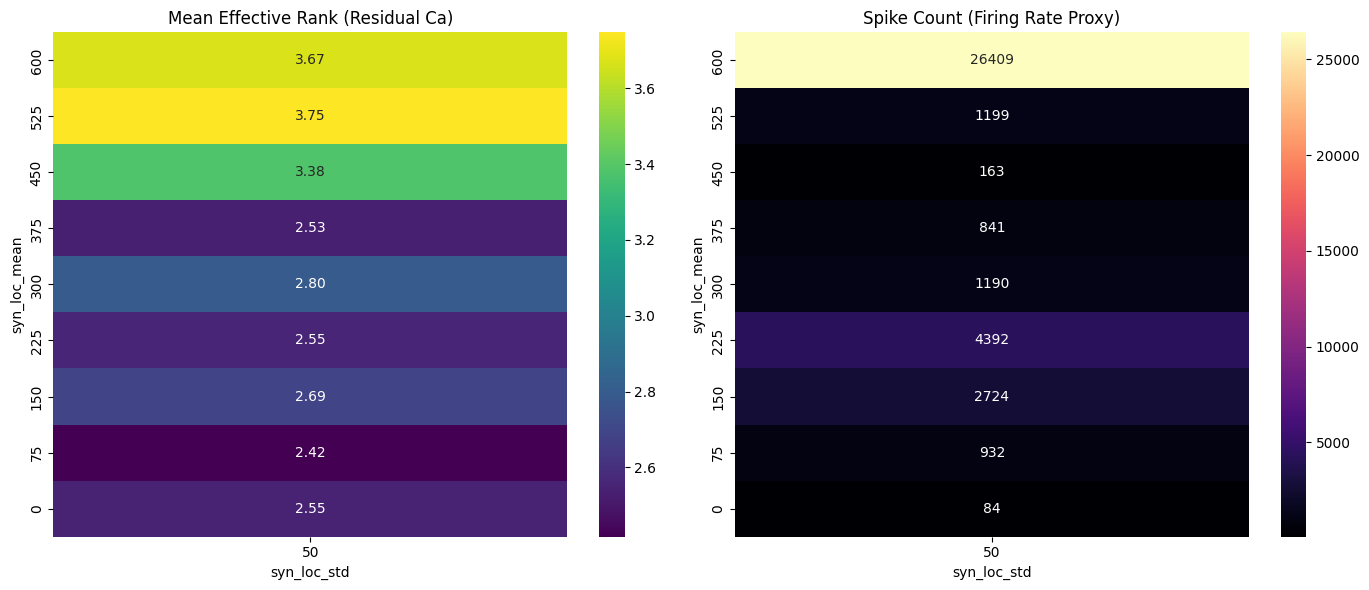

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

if not df_rank.empty:
    # 1. 必要な統計量の算出（実効ランクの平均と発火率）
    # ※ここでは、各条件におけるデータの行数(count)を「発火の頻度（発火率の代理指標）」と仮定します。
    # 厳密な発火率(Hz)が必要な場合は、シミュレーション時間で割る処理を追加してください。
    
    summary_df = df_rank.groupby(['syn_loc_mean', 'syn_loc_std']).agg({
        'er_res': 'mean',        # 残留Caの実効ランク平均
        'spike_type': 'count'    # 総発火数（発火率の指標）
    }).reset_index()

    # 2. ヒートマップ用にピボット
    # 横軸: std, 縦軸: mean
    pivot_er = summary_df.pivot(index='syn_loc_mean', columns='syn_loc_std', values='er_res')
    pivot_rate = summary_df.pivot(index='syn_loc_mean', columns='syn_loc_std', values='spike_type')

    # 3. プロット
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))

    # 実効ランクのヒートマップ
    sns.heatmap(pivot_er, annot=True, fmt=".2f", cmap="viridis", ax=axes[0])
    axes[0].set_title("Mean Effective Rank (Residual Ca)")
    axes[0].invert_yaxis()  # 平均が下から上に大きくなるように調整

    # 発火率のヒートマップ
    sns.heatmap(pivot_rate, annot=True, fmt="d", cmap="magma", ax=axes[1])
    axes[1].set_title("Spike Count (Firing Rate Proxy)")
    axes[1].invert_yaxis()

    plt.tight_layout()
    plt.savefig("heatmap_coarse_grained.png")
    plt.show()
else:
    print("No data available to plot.")

/tmp/ipykernel_7166/3163939688.py:22: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(
/tmp/ipykernel_7166/3163939688.py:34: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(


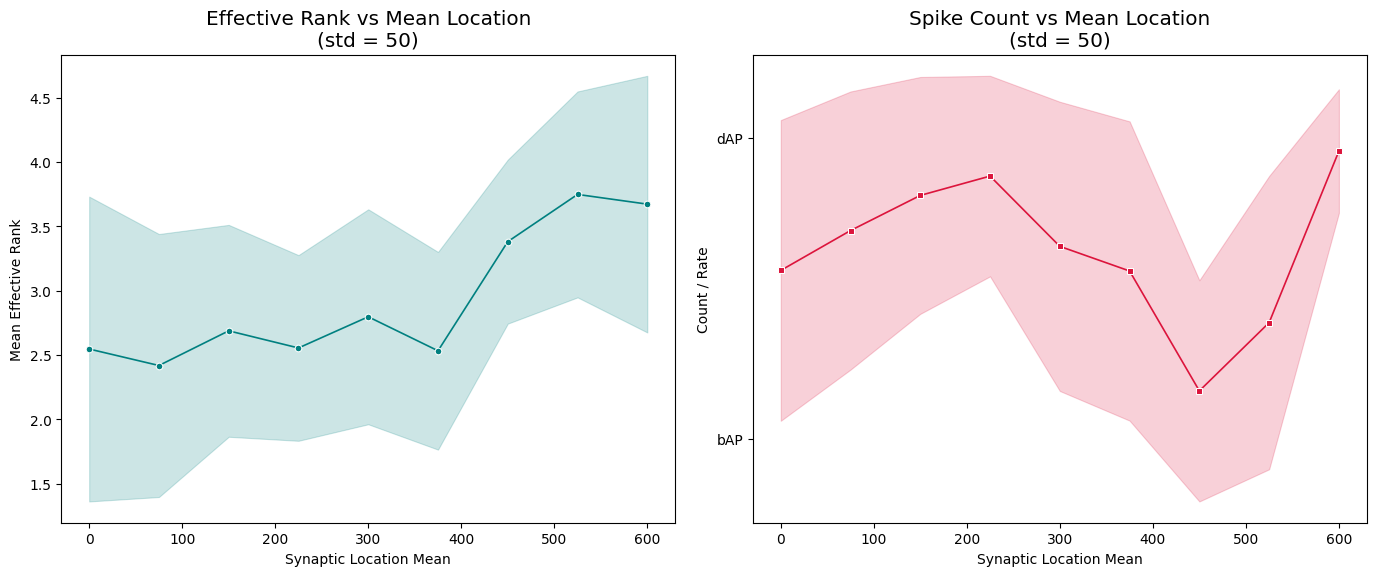

In [6]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# データの確認
if not df_rank.empty:
    # 1. syn_loc_std を特定の値に固定（例: 0.1）
    # ※ どの値に固定するかは、予備実験で最も「筋の良い」結果が出たものを選んでください。
    # 複数のstdを比較したい場合は、filterせずに hue='syn_loc_std' を指定するのも手です。
    target_std = df_rank['syn_loc_std'].unique()[0] # ここでは便宜上最初の値を選択
    df_filtered = df_rank[df_rank['syn_loc_std'] == target_std]

    # プロットの設定
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # スタイル設定（論文向けに少し硬めに）
    sns.set_context("paper", font_scale=1.5)
    sns.set_style("whitegrid")

    # 2. 実効ランクの折れ線グラフ
    # ci='sd' は標準偏差を表示。ci=95 とすれば95%信頼区間になります。
    sns.lineplot(
        data=df_filtered, 
        x='syn_loc_mean', y='er_res', 
        marker='o', errorbar='sd', ax=axes[0], color='teal'
    )
    axes[0].set_title(f"Effective Rank vs Mean Location\n(std = {target_std})")
    axes[0].set_ylabel("Mean Effective Rank")
    axes[0].set_xlabel("Synaptic Location Mean")

    # 3. 発火率（Spike Count）の折れ線グラフ
    # ここでは個々の発火イベントをカウントする必要があるため、
    # 統計処理済みのデータを使うか、元データで集計方法を検討してください。
    sns.lineplot(
        data=df_filtered, 
        x='syn_loc_mean', y='spike_type', # spike_typeがバイナリなら発火率、カウントならそのまま
        marker='s', ci='sd', ax=axes[1], color='crimson'
    )
    axes[1].set_title(f"Spike Count vs Mean Location\n(std = {target_std})")
    axes[1].set_ylabel("Count / Rate")
    axes[1].set_xlabel("Synaptic Location Mean")

    plt.tight_layout()
    plt.savefig("lineplot_with_errorbars.png")
    plt.show()
else:
    print("No data available to plot.")